In [25]:
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit
import numpy as np
from scipy.integrate import solve_ivp 
import os
from os import path
from collections import defaultdict
import time

class UnbalancedDisk(gym.Env):
    def __init__(self, umax=20., dt = 0.025, render_mode='human'):
        self.omega0 = 11.339846957335382
        self.delta_th = 0
        self.gamma = 1.3328339309394384
        self.Ku = 28.136158407237073
        self.Fc = 6.062729509386865
        self.coulomb_omega = 0.001

        self.umax = umax
        self.dt = dt 

        self.action_space = spaces.Box(low=-umax,high=umax,shape=tuple()) 
        low = [-float('inf'),-40] 
        high = [float('inf'),40]
        self.observation_space = spaces.Box(low=np.array(low,dtype=np.float32),high=np.array(high,dtype=np.float32),shape=(2,))

        # A simple cosine reward: highest at the top (pi), lowest at the bottom (0).
        # We also subtract a tiny penalty for high angular velocity.
        self.reward_fun = lambda self: -(np.cos(self.th) + 1) - 0.01 * (self.omega ** 2)        
        
        self.render_mode = render_mode
        self.viewer = None
        self.u = 0 
        self.reset()

    def step(self, action):
        self.u = action 
        self.u = np.clip(self.u,-self.umax,self.umax)
        
        def f(t,y):
            th, omega = y
            dthdt = omega
            friction = self.gamma*omega + self.Fc*np.tanh(omega/self.coulomb_omega)
            domegadt = -self.omega0**2*np.sin(th+self.delta_th) - friction + self.Ku*self.u
            return np.array([dthdt, domegadt])
            
        sol = solve_ivp(f,[0,self.dt],[self.th,self.omega]) 
        self.th, self.omega = sol.y[:,-1]

        reward = self.reward_fun(self)
        return self.get_obs(), reward, False, False, {}
         
    def reset(self, seed=None, options=None):
        # We also need to call super() to properly handle the seed in Gymnasium
        super().reset(seed=seed) 
        
        self.th = np.random.normal(loc=0,scale=0.001)
        self.omega = np.random.normal(loc=0,scale=0.001)
        self.u = 0
        return self.get_obs(), {}

    def get_obs(self):
        self.th_noise = self.th + np.random.normal(loc=0,scale=0.001) 
        self.omega_noise = self.omega + np.random.normal(loc=0,scale=0.001) 
        return np.array([self.th_noise, self.omega_noise])

    def render(self):
        import pygame
        from pygame import gfxdraw
        
        screen_width = 500
        screen_height = 500

        th = self.th
        omega = self.omega 

        if self.viewer is None:
            pygame.init()
            pygame.display.init()
            self.viewer = pygame.display.set_mode((screen_width, screen_height))

        self.surf = pygame.Surface((screen_width, screen_height))
        self.surf.fill((255, 255, 255))
        
        gfxdraw.filled_circle(self.surf, screen_width//2, screen_height//2, int(screen_width/2*0.65*1.3), (32,60,92))
        gfxdraw.filled_circle(self.surf, screen_width//2, screen_height//2, int(screen_width/2*0.06*1.3), (132,132,126))
        
        from math import cos, sin
        r = screen_width//2*0.40*1.3
        gfxdraw.filled_circle(self.surf, int(screen_width//2-sin(th)*r), int(screen_height//2-cos(th)*r), int(screen_width/2*0.22*1.3), (155,140,108))
        gfxdraw.filled_circle(self.surf, int(screen_width//2-sin(th)*r), int(screen_height//2-cos(th)*r), int(screen_width/2*0.22/8*1.3), (71,63,48))
        
        # os.getcwd() gets the notebook's current working directory safely
        fname = os.path.join(os.getcwd(), "clockwise.png")
        try:
            self.arrow = pygame.image.load(fname)
            if self.u:
                if isinstance(self.u, (np.ndarray,list)):
                    if self.u.ndim==1:
                        u = self.u[0]
                    elif self.u.ndim==0:
                        u = self.u
                    else:
                        raise ValueError(f'u={u} is not the correct shape')
                else:
                    u = self.u
                arrow_size = abs(float(u)/self.umax*screen_height)*0.25
                Z = (arrow_size, arrow_size)
                arrow_rot = pygame.transform.scale(self.arrow,Z)
                if self.u<0:
                    arrow_rot = pygame.transform.flip(arrow_rot, True, False)
                    
            self.surf = pygame.transform.flip(self.surf, False, True)
            self.viewer.blit(self.surf, (0, 0))
            if self.u:
                self.viewer.blit(arrow_rot, (screen_width//2-arrow_size//2, screen_height//2-arrow_size//2))
        except FileNotFoundError:
            self.surf = pygame.transform.flip(self.surf, False, True)
            self.viewer.blit(self.surf, (0, 0))
            
        if self.render_mode == "human":
            pygame.event.pump()
            pygame.display.flip()

        return True

    def close(self):
        if self.viewer is not None:
            import pygame
            pygame.display.quit()
            pygame.quit()
            self.isopen = False
            self.viewer = None

class UnbalancedDisk_sincos(UnbalancedDisk):
    def __init__(self, umax=3., dt = 0.025):
        super(UnbalancedDisk_sincos, self).__init__(umax=umax, dt=dt)
        low = [-1,-1,-40.] 
        high = [1,1,40.]
        self.observation_space = spaces.Box(low=np.array(low,dtype=np.float32),high=np.array(high,dtype=np.float32),shape=(3,))

    def get_obs(self):
        self.th_noise = self.th + np.random.normal(loc=0,scale=0.001) 
        self.omega_noise = self.omega + np.random.normal(loc=0,scale=0.001) 
        return np.array([np.sin(self.th_noise), np.cos(self.th_noise), self.omega_noise])

In [26]:
class Discretize_obs(gym.ObservationWrapper):
    def __init__(self, env, nvec=10):
        super().__init__(env)
        if isinstance(nvec, int):
            self.nvec_array = np.array([nvec] * np.prod(env.observation_space.shape, dtype=int))
        else:
            self.nvec_array = np.array(nvec)
            
        self.observation_space = gym.spaces.MultiDiscrete(self.nvec_array)
        self.olow = env.observation_space.low
        self.ohigh = env.observation_space.high

    def observation(self, obs):
        scaled = (obs - self.olow) / (self.ohigh - self.olow) * self.nvec_array
        discretized = np.clip(scaled, 0, self.nvec_array - 1).astype(int)
        return tuple(discretized)

class DiscretizeAction(gym.ActionWrapper):
    def __init__(self, env, bins=5):
        super().__init__(env)
        self.bins = bins
        self.action_space = gym.spaces.Discrete(self.bins)
        
        low = np.atleast_1d(env.action_space.low)[0]
        high = np.atleast_1d(env.action_space.high)[0]
        
        self.action_mapping = np.linspace(low, high, self.bins)

    def action(self, act):
        # Cast the selected mapping directly to a float (scalar)
        return float(self.action_mapping[act])

def argmax(a):
    a = np.array(a)
    return np.random.choice(np.arange(len(a), dtype=int)[a == np.max(a)])

def Qlearn(env, nsteps=5000, alpha=0.2, eps_start=1.0, eps_end=0.01, gamma=0.99):
    Qmat = defaultdict(float)

    history = {
        "episode_rewards": [],
        "episode_lengths": [],
        "episode_end_steps": [],
        "epsilons": [],
        "td_errors": []
    }

    obs, info = env.reset()
    print(f"Training started for {nsteps} steps...")

    total_reward = 0
    episode_length = 0

    for z in range(nsteps):
        # Linear epsilon decay
        eps = eps_start - (eps_start - eps_end) * (z / nsteps)
        history["epsilons"].append(eps)

        # Epsilon-greedy action selection
        if np.random.uniform() < eps:
            action = env.action_space.sample()
        else:
            action = argmax([Qmat[obs, a] for a in range(env.action_space.n)])

        obs_new, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-learning update
        if done:
            target = reward
        else:
            max_q_next = max(Qmat[obs_new, a] for a in range(env.action_space.n))
            target = reward + gamma * max_q_next

        td_error = target - Qmat[obs, action]
        Qmat[obs, action] += alpha * td_error

        history["td_errors"].append(abs(td_error))

        total_reward += reward
        episode_length += 1

        if done:
            history["episode_rewards"].append(total_reward)
            history["episode_lengths"].append(episode_length)
            history["episode_end_steps"].append(z)

            obs, info = env.reset()
            total_reward = 0
            episode_length = 0
        else:
            obs = obs_new

    print("Training complete.")
    return Qmat, history

def save_qmat(Qmat, filename):
    rows = []

    for (obs, action), q_value in Qmat.items():
        # obs is something like (theta_bin, omega_bin, ...)
        row = list(obs) + [action, q_value]
        rows.append(row)

    rows = np.array(rows, dtype=float)
    np.savez_compressed(filename, rows=rows)


def load_qmat(filename, obs_dim):
    data = np.load(filename)
    rows = data["rows"]

    Qmat = defaultdict(float)

    for row in rows:
        obs = tuple(row[:obs_dim].astype(int))
        action = int(row[obs_dim])
        q_value = float(row[obs_dim + 1])

        Qmat[obs, action] = q_value

    return Qmat

In [27]:
env = UnbalancedDisk_sincos(umax=3.0, dt=0.025)

env = TimeLimit(env, max_episode_steps=200)

# discretize observations
env = Discretize_obs(env, nvec=30)

# discretize actions
env = DiscretizeAction(env, bins=11)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: MultiDiscrete([30 30 30])
Action space: Discrete(11)


### Load existing model, otherwise train model

In [35]:
from pathlib import Path

qmat_path = Path("Qmat_unbalanced_disk.npz")
history_path = Path("Qlearn_history.npz")

obs_dim = 3
train = 1
if qmat_path.exists() and train == 0:
    print("Loading saved Qmat")
    Qmat = load_qmat(qmat_path, obs_dim)

    if history_path.exists():
        print("Loading saved training history")
        h = np.load(history_path)
        history = {key: h[key] for key in h.files}
    else:
        print("No training history found")
        history = None

else:
    print("No saved Qmat found, training")
    Qmat, history = Qlearn(
        env,
        nsteps=2500000,
        alpha=0.2,
        eps_start=0.9,
        eps_end=0.01,
        gamma=0.99
    )

    save_qmat(Qmat, qmat_path)
    print("Qmat saved")

    np.savez(
        history_path,
        episode_rewards=np.array(history["episode_rewards"]),
        episode_lengths=np.array(history["episode_lengths"]),
        episode_end_steps=np.array(history["episode_end_steps"]),
        epsilons=np.array(history["epsilons"]),
        td_errors=np.array(history["td_errors"])
    )

    print("Training history saved")

No saved Qmat found, training
Training started for 2500000 steps...
Training complete.
Qmat saved
Training history saved


In [36]:
# 5. Test and Render the Trained Policy
print("Testing the trained policy...")

obs, info = env.reset()
print(Qmat)
try:
    for i in range(1000000):
        action = argmax([Qmat[obs, a] for a in range(env.action_space.n)])
        obs, reward, terminated, truncated, info = env.step(action)
        
        env.render()
        time.sleep(0.025) # Sleep to match the dt of the physics engine
        
        if terminated or truncated:
            print("Test episode finished!")
            break
finally:
    env.close() # Closes Pygame safely to save your Jupyter Kernel!

Testing the trained policy...
defaultdict(<class 'float'>, {((np.int64(15), np.int64(29), np.int64(15)), 0): np.float64(-51.830087293041885), ((np.int64(15), np.int64(29), np.int64(15)), 1): np.float64(-52.50501433452449), ((np.int64(15), np.int64(29), np.int64(15)), 2): np.float64(-51.683133237407205), ((np.int64(15), np.int64(29), np.int64(15)), 3): np.float64(-51.8661066226929), ((np.int64(15), np.int64(29), np.int64(15)), 4): np.float64(-51.32527358135695), ((np.int64(15), np.int64(29), np.int64(15)), 5): np.float64(-51.812961574538264), ((np.int64(15), np.int64(29), np.int64(15)), 6): np.float64(-51.43189077747247), ((np.int64(15), np.int64(29), np.int64(15)), 7): np.float64(-51.29643053022415), ((np.int64(15), np.int64(29), np.int64(15)), 8): np.float64(-51.21791162537443), ((np.int64(15), np.int64(29), np.int64(15)), 9): np.float64(-51.26688766072621), ((np.int64(15), np.int64(29), np.int64(15)), 10): np.float64(-49.83835591693199), ((np.int64(14), np.int64(29), np.int64(15)), n

### Training Plots

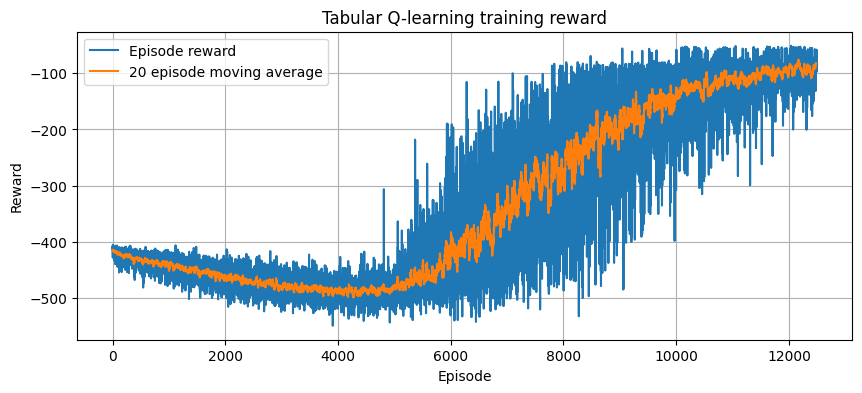

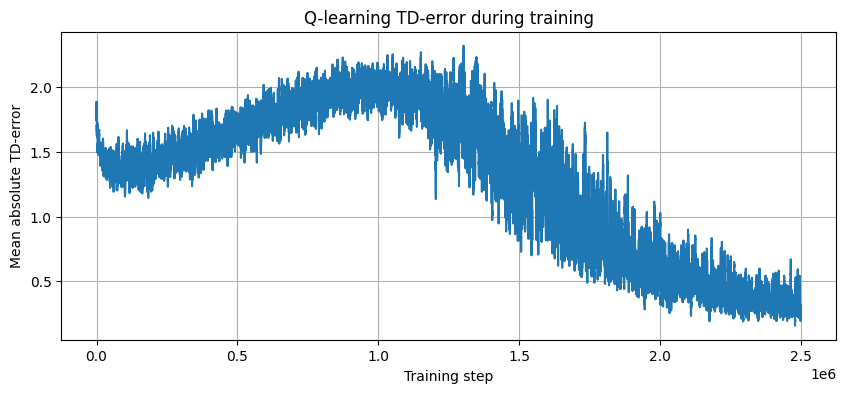

In [37]:
import matplotlib.pyplot as plt


def moving_average(x, window=20):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


# Episode reward
rewards = np.array(history["episode_rewards"])

plt.figure(figsize=(10, 4))
plt.plot(rewards, label="Episode reward")
plt.plot(
    range(len(moving_average(rewards, 20))),
    moving_average(rewards, 20),
    label="20 episode moving average"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Tabular Q-learning training reward")
plt.legend()
plt.grid(True)
plt.show()


# TD-error instead of DQN loss
td_errors = np.array(history["td_errors"])

plt.figure(figsize=(10, 4))
plt.plot(moving_average(td_errors, 1000))
plt.xlabel("Training step")
plt.ylabel("Mean absolute TD-error")
plt.title("Q-learning TD-error during training")
plt.grid(True)
plt.show()


### Policy evaluation

In [38]:
def evaluate_q_policy(env, Qmat, episodes=20, render=False):
    rewards = []
    lengths = []
    mean_abs_u = []
    mean_abs_du = []
    mean_abs_angle_error = []
    mean_abs_omega = []

    for ep in range(episodes):
        obs, info = env.reset()
        done = False

        total_reward = 0
        episode_length = 0

        u_values = []
        angle_errors = []
        omega_values = []

        while not done:
            action = argmax([Qmat[obs, a] for a in range(env.action_space.n)])

            # Get continuous action value from the action wrapper
            if hasattr(env, "action_mapping"):
                selected_u = float(env.action_mapping[action])
            else:
                selected_u = np.nan

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            base_env = env.unwrapped

            th = float(getattr(base_env, "th", np.nan))
            omega = float(getattr(base_env, "omega", np.nan))
            u = float(getattr(base_env, "u", selected_u))

            # angle error relative to upright position pi
            angle_error = ((th - np.pi + np.pi) % (2 * np.pi)) - np.pi

            u_values.append(u)
            angle_errors.append(abs(angle_error))
            omega_values.append(abs(omega))

            total_reward += reward
            episode_length += 1

            if render:
                env.render()

        rewards.append(total_reward)
        lengths.append(episode_length)
        mean_abs_u.append(np.mean(np.abs(u_values)))
        mean_abs_du.append(np.mean(np.abs(np.diff(u_values))) if len(u_values) > 1 else 0)
        mean_abs_angle_error.append(np.mean(angle_errors))
        mean_abs_omega.append(np.mean(omega_values))

    results = {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "mean_length": np.mean(lengths),
        "mean_abs_u": np.mean(mean_abs_u),
        "mean_abs_du": np.mean(mean_abs_du),
        "mean_abs_angle_error_rad": np.mean(mean_abs_angle_error),
        "mean_abs_angle_error_deg": np.mean(mean_abs_angle_error) / (2 * np.pi) * 360,
        "mean_abs_omega": np.mean(mean_abs_omega),
    }

    return results


results = evaluate_q_policy(env, Qmat, episodes=20, render=False)

for key, value in results.items():
    print(f"{key}: {value:.4f}")

mean_reward: -80.9291
std_reward: 6.4588
mean_length: 200.0000
mean_abs_u: 0.7233
mean_abs_du: 0.8005
mean_abs_angle_error_rad: 0.4084
mean_abs_angle_error_deg: 23.4003
mean_abs_omega: 1.5028


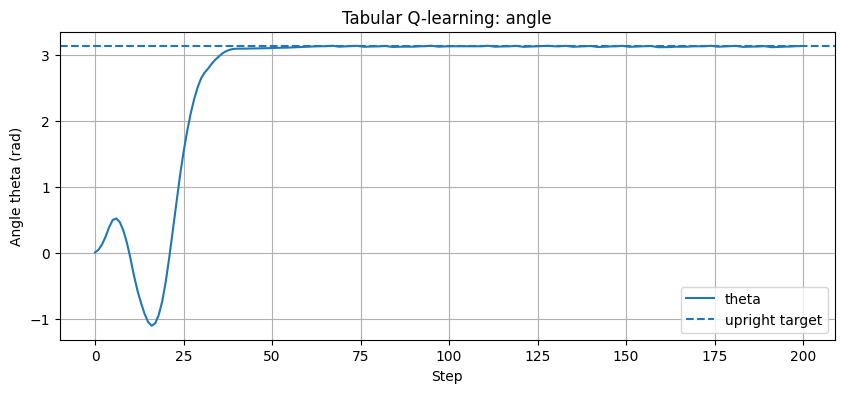

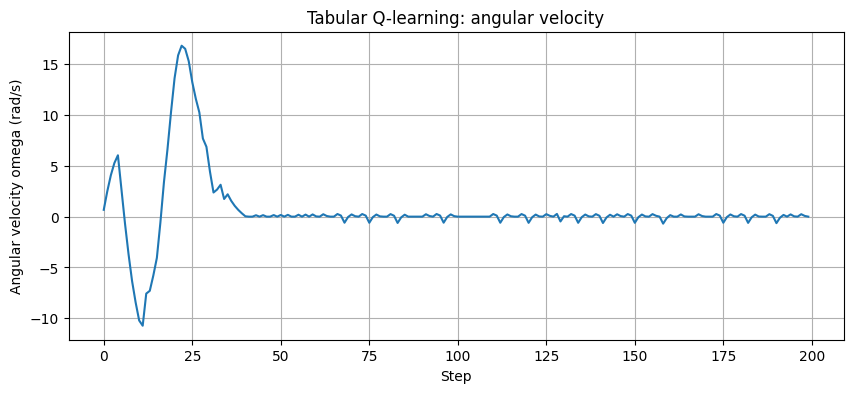

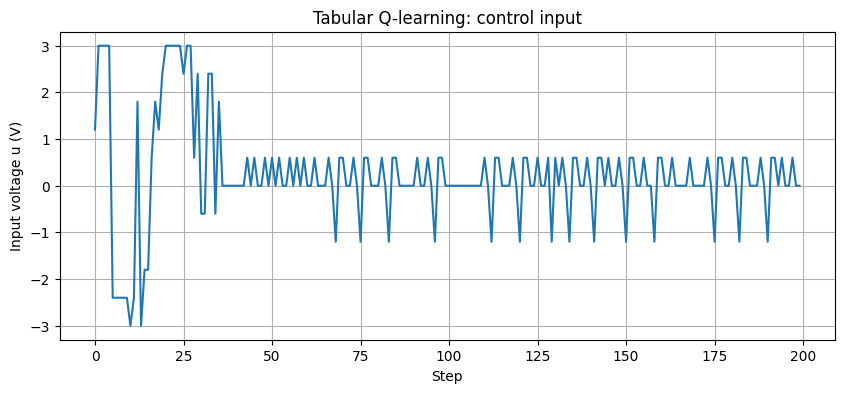

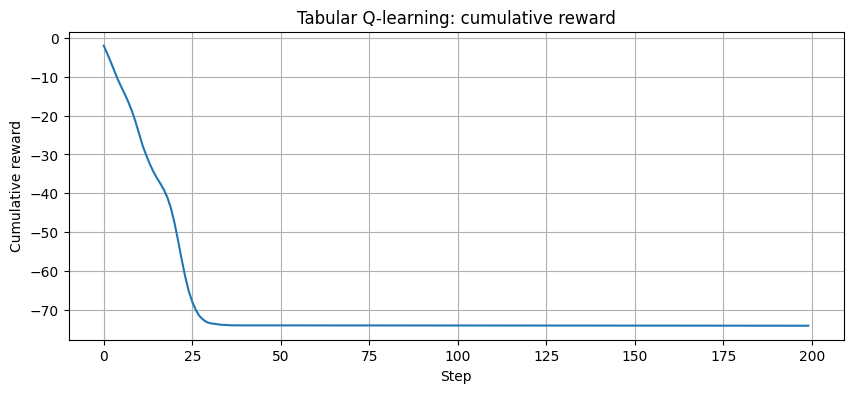

In [39]:
def rollout_q_policy(env, Qmat, max_steps=200):
    obs, info = env.reset()
    done = False

    theta_values = []
    omega_values = []
    u_values = []
    reward_values = []

    for step in range(max_steps):
        action = argmax([Qmat[obs, a] for a in range(env.action_space.n)])

        if hasattr(env, "action_mapping"):
            selected_u = float(env.action_mapping[action])
        else:
            selected_u = np.nan

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        base_env = env.unwrapped

        th = float(getattr(base_env, "th", np.nan))
        omega = float(getattr(base_env, "omega", np.nan))
        u = float(getattr(base_env, "u", selected_u))

        theta_values.append(th)
        omega_values.append(omega)
        u_values.append(u)
        reward_values.append(reward)

        if done:
            break

    return {
        "theta": np.array(theta_values),
        "omega": np.array(omega_values),
        "u": np.array(u_values),
        "reward": np.array(reward_values),
    }


rollout = rollout_q_policy(env, Qmat, max_steps=200)

plt.figure(figsize=(10, 4))
plt.plot(rollout["theta"], label="theta")
plt.axhline(np.pi, linestyle="--", label="upright target")
plt.xlabel("Step")
plt.ylabel("Angle theta (rad)")
plt.title("Tabular Q-learning: angle")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(rollout["omega"])
plt.xlabel("Step")
plt.ylabel("Angular velocity omega (rad/s)")
plt.title("Tabular Q-learning: angular velocity")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(rollout["u"])
plt.xlabel("Step")
plt.ylabel("Input voltage u (V)")
plt.title("Tabular Q-learning: control input")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(rollout["reward"]))
plt.xlabel("Step")
plt.ylabel("Cumulative reward")
plt.title("Tabular Q-learning: cumulative reward")
plt.grid(True)
plt.show()